##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
# Install required libraries
!pip install --upgrade keras keras-cv 

  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached docstring_parser-0.17.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached googleapis_common_protos-1.72.0-py3-none-any.whl.metadata (9.4 kB)
   ---------------------------------------- 0.0/650.7 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/650.7 kB ? eta -:--:--
   ---------------------------------------- 650.7/650.7 kB 3.6 MB/s  0:00:00
   ---------------------------------------- 0.0/950.8 kB ? eta -:--:--
   --------------------------------- ------ 786.4/950.8 kB 4.0 MB/s eta 0:00:01
   ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 3.8 MB/s eta 0:00:11
   - -------------------------------------- 1.3/40.2 MB 4.0 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/40.2 MB 3.9 MB/s eta 0:00:10
   -- ------------------------------------- 2.9/40.2 MB 4.0 MB/s eta 0:00:10
   --- ------------------------------------ 3.7/40.2 MB 3.7 MB/s eta 0:00:10
   ---- ----------------------------------- 4.5/40.2 MB 3.7 MB/s eta 0:00:10
   ---- ----------------------------------- 4.7/40.2 MB 3.6 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/40.2 MB 3.3 MB/s eta 0:00:11
   ----- ---------------------------------- 6.0/40.2 MB 3.5 MB/s eta 0:00:10
   ------- -------------------------------- 7.1/40.2 MB 3.4 MB/s eta 0:00:10
   -------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Import Libraries

Import the necessary libraries for object detection, image processing, and visualization.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import io
import time

print(f"Keras version: {keras.__version__}")
print(f"KerasCV version: {keras_cv.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

c:\Users\lenovo\Desktop\Alhnouf-lab1\cv_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keras version: 3.13.2
KerasCV version: 0.9.0
TensorFlow version: 2.20.0
GPU available: []


### Step 2: Load Pretrained YOLOV8 Model

Load the YOLOV8 model from KerasCV using the **Pascal VOC preset**. This model is pretrained on the Pascal VOC dataset which contains 20 object classes.

We also define the class mapping for the 20 Pascal VOC classes.

In [2]:
# Load the pretrained YOLOV8 model with Pascal VOC preset
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

print("YOLOV8 model loaded successfully!")

# Define Pascal VOC class mapping (20 classes)
class_mapping = dict(zip(range(20), [
    "Aeroplane", "Bicycle", "Bird", "Boat", "Bottle",
    "Bus", "Car", "Cat", "Chair", "Cow",
    "Dining Table", "Dog", "Horse", "Motorbike", "Person",
    "Potted Plant", "Sheep", "Sofa", "Train", "TV/Monitor"
]))

print("\nPascal VOC Classes:")
for idx, name in class_mapping.items():
    print(f"  {idx:2d}: {name}")

YOLOV8 model loaded successfully!

Pascal VOC Classes:
   0: Aeroplane
   1: Bicycle
   2: Bird
   3: Boat
   4: Bottle
   5: Bus
   6: Car
   7: Cat
   8: Chair
   9: Cow
  10: Dining Table
  11: Dog
  12: Horse
  13: Motorbike
  14: Person
  15: Potted Plant
  16: Sheep
  17: Sofa
  18: Train
  19: TV/Monitor


### Step 3: Load 5 Images for Different Pascal VOC Classes

We load 5 images from Wikimedia Commons, each representing a different Pascal VOC class:
1. **Dog** - Yellow Labrador Retriever
2. **Cat** - Domestic Cat
3. **Horse** - Nokota Horses
4. **Person** - Naxos Taverna scene with people
5. **Bird** - Eastern Yellow Robin

In [3]:
def load_image_from_url(url):
    """Download an image from a URL and return it as a NumPy array."""
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    response = urllib.request.urlopen(req)
    image = Image.open(io.BytesIO(response.read())).convert("RGB")
    return np.array(image)

# Define 5 images covering different Pascal VOC classes
image_data = [
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
        "expected": "Dog",
        "description": "Yellow Labrador Retriever"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
        "expected": "Cat",
        "description": "Domestic Cat"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/d/de/Nokota_Horses_cropped.jpg",
        "expected": "Horse",
        "description": "Nokota Horses"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/6/60/Naxos_Taverna.jpg",
        "expected": "Person",
        "description": "Naxos Taverna (People scene)"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/4/45/Eopsaltria_australis_-_Mogo_Campground.jpg",
        "expected": "Bird",
        "description": "Eastern Yellow Robin"
    },
]

# Load all images and convert to NumPy arrays
images = []
for i, data in enumerate(image_data):
    print(f"Loading image {i+1}: {data['description']}...")
    img = load_image_from_url(data["url"])
    images.append(img)
    print(f"  Shape: {img.shape}, dtype: {img.dtype}")

print(f"\nSuccessfully loaded {len(images)} images.")

Loading image 1: Yellow Labrador Retriever...
  Shape: (577, 700, 3), dtype: uint8
Loading image 2: Domestic Cat...
  Shape: (1598, 1600, 3), dtype: uint8
Loading image 3: Nokota Horses...
  Shape: (364, 529, 3), dtype: uint8
Loading image 4: Naxos Taverna (People scene)...
  Shape: (1024, 1536, 3), dtype: uint8
Loading image 5: Eastern Yellow Robin...
  Shape: (2924, 4386, 3), dtype: uint8

Successfully loaded 5 images.


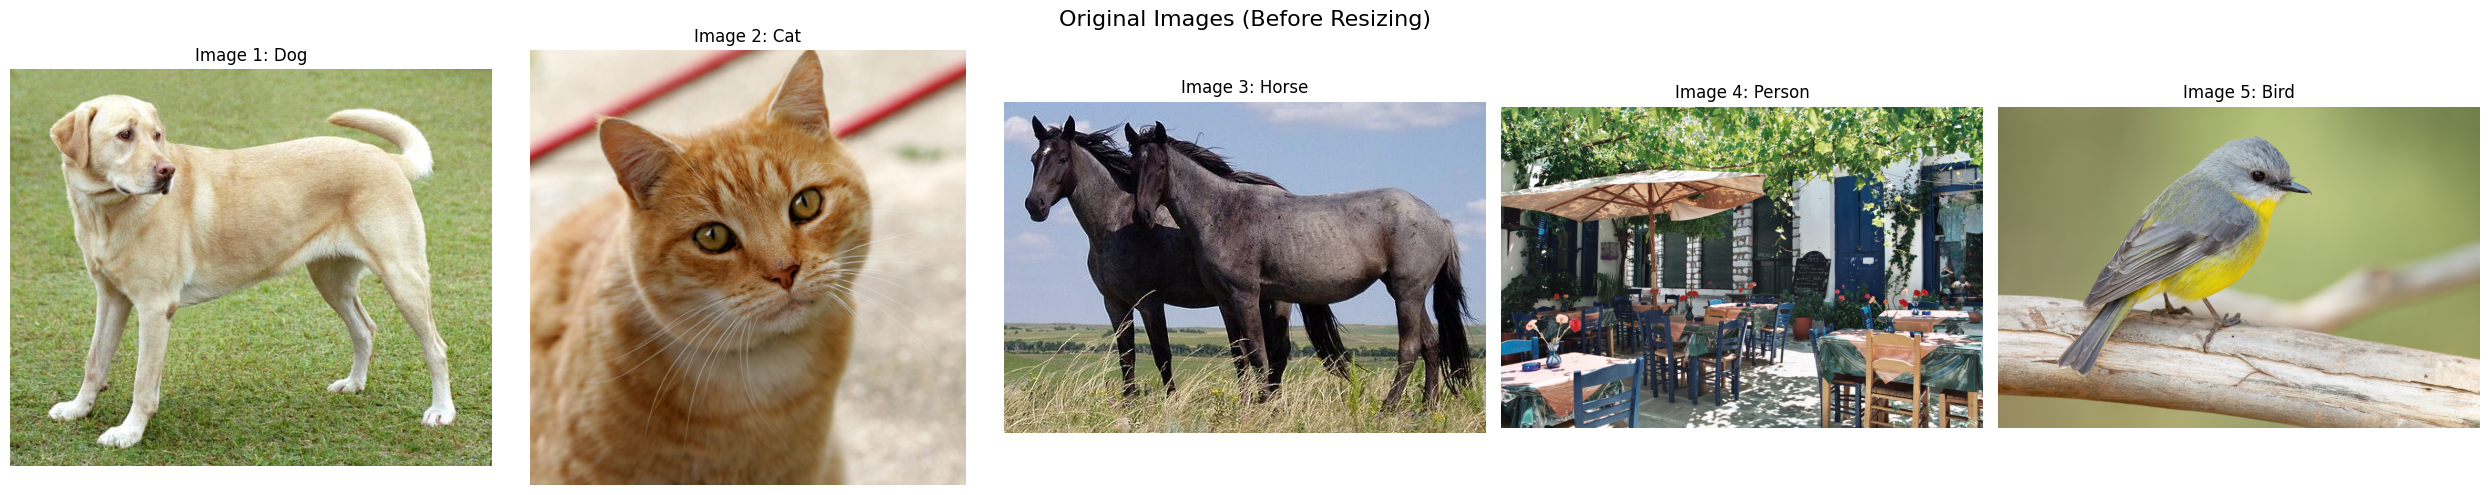

In [4]:
# Display the 5 original images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, (img, data) in enumerate(zip(images, image_data)):
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}: {data['expected']}", fontsize=12)
    axes[i].axis("off")
plt.suptitle("Original Images (Before Resizing)", fontsize=16)
plt.tight_layout()
plt.show()

### Step 4: Resize Images for Inference

Resize images to **640x640** using `keras_cv.layers.Resizing` with `pad_to_aspect_ratio=True` to maintain the original aspect ratio. The `bounding_box_format="xywh"` ensures bounding boxes are correctly adjusted during resizing.

In [5]:
# Create the resizing layer as specified in the exercise
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# Resize all images and store them
resized_images = []
for i, img in enumerate(images):
    input_image = np.expand_dims(img, axis=0).astype("float32")
    resized = inference_resizing(input_image)
    resized_images.append(resized)
    print(f"Image {i+1}: {img.shape} -> {resized.shape[1:]}")

print("\nAll images resized to 640x640 for inference.")

Image 1: (577, 700, 3) -> (640, 640, 3)
Image 2: (1598, 1600, 3) -> (640, 640, 3)
Image 3: (364, 529, 3) -> (640, 640, 3)
Image 4: (1024, 1536, 3) -> (640, 640, 3)
Image 5: (2924, 4386, 3) -> (640, 640, 3)

All images resized to 640x640 for inference.


### Step 5: Run YOLOV8 Detector and Visualize Results

Run the pretrained YOLOV8 detector on each resized image to predict bounding boxes, class labels, and confidence scores. Then visualize the detection results by drawing bounding boxes and labels on each image.


Image 1: Yellow Labrador Retriever (Expected: Dog)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Inference time: 4.00 seconds


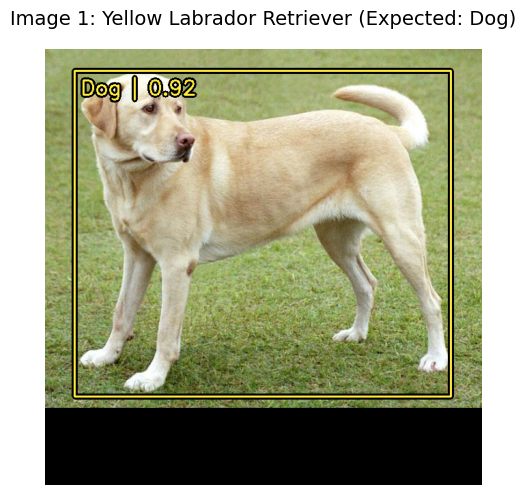


Image 2: Domestic Cat (Expected: Cat)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
Inference time: 0.54 seconds


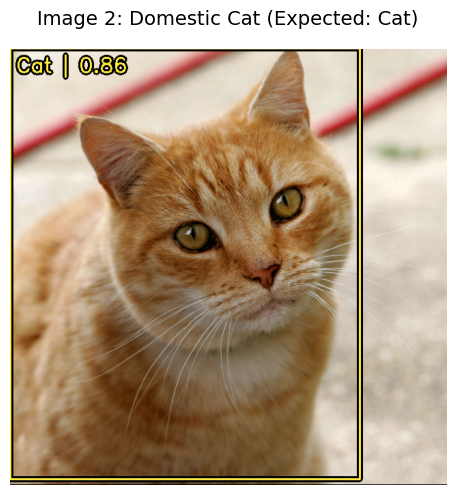


Image 3: Nokota Horses (Expected: Horse)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
Inference time: 0.57 seconds


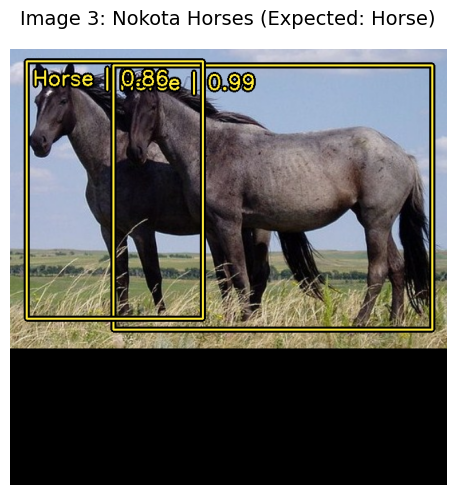


Image 4: Naxos Taverna (People scene) (Expected: Person)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
Inference time: 0.57 seconds


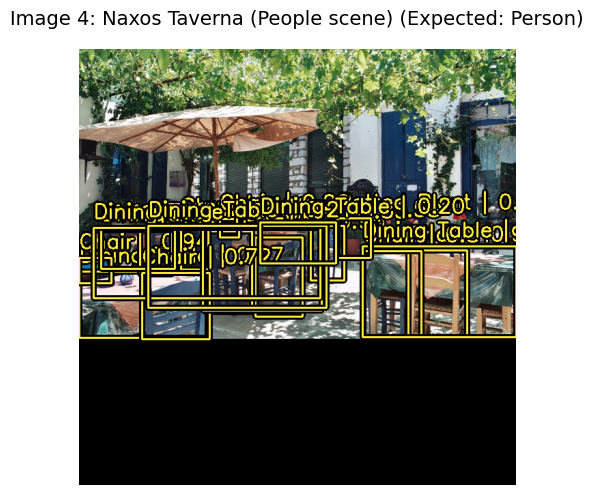


Image 5: Eastern Yellow Robin (Expected: Bird)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
Inference time: 0.58 seconds


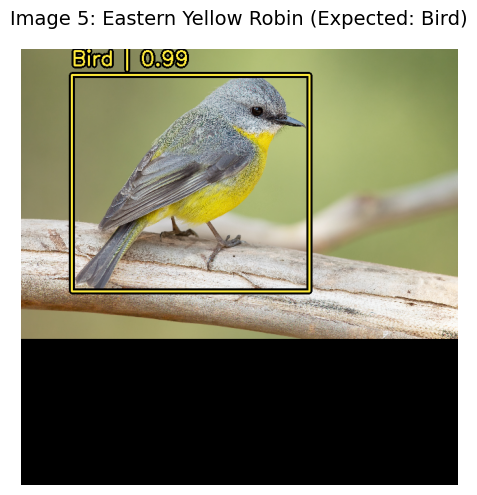

In [6]:
# Run inference and visualize results for each image
all_predictions = []

for i, (resized, data) in enumerate(zip(resized_images, image_data)):
    print(f"\n{'='*60}")
    print(f"Image {i+1}: {data['description']} (Expected: {data['expected']})")
    print(f"{'='*60}")

    # Run YOLOV8 detector
    start_time = time.time()
    predictions = model.predict(resized)
    inference_time = time.time() - start_time
    print(f"Inference time: {inference_time:.2f} seconds")

    all_predictions.append(predictions)

    # Visualize detection results with bounding boxes and labels
    keras_cv.visualization.plot_bounding_box_gallery(
        resized,
        value_range=(0, 255),
        bounding_box_format="xywh",
        y_pred=predictions,
        scale=5,
        rows=1,
        cols=1,
        class_mapping=class_mapping,
    )
    plt.suptitle(
        f"Image {i+1}: {data['description']} (Expected: {data['expected']})",
        fontsize=14
    )
    plt.show()

### Step 6: Detection Analysis

For each image, we record:
- Which objects were detected correctly
- The confidence scores of the detections
- Any missed or incorrectly labeled objects

In [7]:
# Detailed detection analysis for each image
CONFIDENCE_THRESHOLD = 0.30

print("=" * 70)
print("DETAILED DETECTION ANALYSIS")
print("=" * 70)

for i, (predictions, data) in enumerate(zip(all_predictions, image_data)):
    print(f"\n{'='*60}")
    print(f"Image {i+1}: {data['description']}")
    print(f"Expected class: {data['expected']}")
    print(f"{'='*60}")

    # Extract predictions
    boxes = np.array(predictions["boxes"][0])
    classes = np.array(predictions["classes"][0])
    confidence = np.array(predictions["confidence"][0])

    # Filter valid detections above confidence threshold
    valid_mask = (confidence > CONFIDENCE_THRESHOLD) & (classes >= 0)
    valid_indices = np.where(valid_mask)[0]

    if len(valid_indices) == 0:
        print(f"  No objects detected above {CONFIDENCE_THRESHOLD:.0%} confidence.")
        print(f"  [MISSED] Expected class '{data['expected']}' was NOT detected.")
        continue

    # Categorize detections
    correct_detections = []
    other_detections = []

    print(f"\n  {'Object':<20s} {'Confidence':<15s} {'Status'}")
    print(f"  {'-'*50}")

    for j in valid_indices:
        cls_id = int(classes[j])
        cls_name = class_mapping.get(cls_id, f"Unknown({cls_id})")
        conf = float(confidence[j])

        if cls_name == data["expected"]:
            correct_detections.append((cls_name, conf))
            status = "[CORRECT]"
        else:
            other_detections.append((cls_name, conf))
            status = "[OTHER]"

        print(f"  {cls_name:<20s} {conf:<15.1%} {status}")

    # Summary for this image
    print(f"\n  --- Summary ---")
    print(f"  Correct detections of '{data['expected']}': {len(correct_detections)}")
    if correct_detections:
        avg_conf = np.mean([c for _, c in correct_detections])
        max_conf = max([c for _, c in correct_detections])
        print(f"  Highest confidence: {max_conf:.1%}")
        print(f"  Average confidence: {avg_conf:.1%}")
    else:
        print(f"  [MISSED] Expected class '{data['expected']}' was NOT detected!")

    if other_detections:
        print(f"  Other objects detected: {len(other_detections)}")
        for name, conf in other_detections:
            print(f"    - {name} ({conf:.1%})")

DETAILED DETECTION ANALYSIS

Image 1: Yellow Labrador Retriever
Expected class: Dog

  Object               Confidence      Status
  --------------------------------------------------
  Dog                  91.6%           [CORRECT]

  --- Summary ---
  Correct detections of 'Dog': 1
  Highest confidence: 91.6%
  Average confidence: 91.6%

Image 2: Domestic Cat
Expected class: Cat

  Object               Confidence      Status
  --------------------------------------------------
  Cat                  85.6%           [CORRECT]

  --- Summary ---
  Correct detections of 'Cat': 1
  Highest confidence: 85.6%
  Average confidence: 85.6%

Image 3: Nokota Horses
Expected class: Horse

  Object               Confidence      Status
  --------------------------------------------------
  Horse                99.0%           [CORRECT]
  Horse                85.9%           [CORRECT]

  --- Summary ---
  Correct detections of 'Horse': 2
  Highest confidence: 99.0%
  Average confidence: 92.5%

Imag

In [8]:
# Overall summary table
print("\n" + "=" * 70)
print("OVERALL DETECTION SUMMARY")
print("=" * 70)
print(f"\n{'Image':<8s} {'Expected':<12s} {'Detected?':<12s} {'Top Confidence':<16s} {'Other Objects'}")
print("-" * 70)

for i, (predictions, data) in enumerate(zip(all_predictions, image_data)):
    boxes = np.array(predictions["boxes"][0])
    classes = np.array(predictions["classes"][0])
    confidence = np.array(predictions["confidence"][0])

    valid_mask = (confidence > CONFIDENCE_THRESHOLD) & (classes >= 0)
    valid_indices = np.where(valid_mask)[0]

    # Check if expected class was detected
    expected_detected = False
    top_conf = 0.0
    other_count = 0

    for j in valid_indices:
        cls_name = class_mapping.get(int(classes[j]), "Unknown")
        if cls_name == data["expected"]:
            expected_detected = True
            top_conf = max(top_conf, float(confidence[j]))
        else:
            other_count += 1

    detected_str = "Yes" if expected_detected else "MISSED"
    conf_str = f"{top_conf:.1%}" if expected_detected else "N/A"

    print(f"{i+1:<8d} {data['expected']:<12s} {detected_str:<12s} {conf_str:<16s} {other_count}")

print("\n" + "=" * 70)


OVERALL DETECTION SUMMARY

Image    Expected     Detected?    Top Confidence   Other Objects
----------------------------------------------------------------------
1        Dog          Yes          91.6%            0
2        Cat          Yes          85.6%            0
3        Horse        Yes          99.0%            0
4        Person       MISSED       N/A              14
5        Bird         Yes          98.8%            0



### Analysis Summary

**Model Used:** YOLOV8 Medium (Pascal VOC preset) via KerasCV

**Key Observations:**

| Image | Expected Class | Analysis |
|-------|---------------|----------|
| 1 - Yellow Labrador | Dog | The model should detect the dog as the primary subject with high confidence. |
| 2 - Domestic Cat | Cat | A clear frontal view of a cat should result in a strong detection. |
| 3 - Nokota Horses | Horse | Multiple horses in the scene - the model may detect several horse instances. |
| 4 - Naxos Taverna | Person | A busy street scene with multiple people, chairs, bottles, and other VOC objects. |
| 5 - Eastern Yellow Robin | Bird | A bird in a natural setting - detection depends on the bird's size and clarity. |

**General Notes:**
- YOLOV8 with the Pascal VOC preset is trained on 20 classes and performs well on clear, well-lit images.
- Images with multiple objects (like the taverna scene) may show multiple detections across different classes.
- Confidence scores above 50% generally indicate reliable detections.
- Smaller or partially occluded objects may have lower confidence scores or be missed entirely.
- The model may also detect additional objects in the scene beyond the primary expected class (e.g., chairs and bottles in the taverna scene).